# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

In [ ]:
import pandas as pd
import seaborn as sns
## Define Pandas display format
# pd.set_option('display.float_format', lambda x: '%.2f' % x)
# pd.set_option('display.max_rows', 1000)


Load your own cleaned DataFrames

In [3]:
# orders_cl.csv
o_cl = pd.read_csv('../data/cleaned_orders_file.csv')
# orderlines_cl.csv
ol_cl = pd.read_csv('../data/cleaned_orderlines_file.csv')
# products_cl.csv
p_cl = pd.read_csv('../data/cleaned_products_file.csv')
# brands
b_cl = pd.read_csv('../data/cleaned_brands_file.csv')

In [5]:
ol_cl.date = pd.to_datetime(ol_cl.date)
ol_cl.info()


<class 'pandas.DataFrame'>
RangeIndex: 257814 entries, 0 to 257813
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                257814 non-null  int64         
 1   id_order          257814 non-null  int64         
 2   product_id        257814 non-null  int64         
 3   product_quantity  257814 non-null  int64         
 4   sku               257814 non-null  str           
 5   unit_price        257814 non-null  float64       
 6   date              257814 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 13.8 MB


In [6]:
o_cl.created_date = pd.to_datetime(o_cl.created_date)
o_cl.info()

<class 'pandas.DataFrame'>
RangeIndex: 226904 entries, 0 to 226903
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  int64         
 1   created_date  226904 non-null  datetime64[us]
 2   total_paid    226904 non-null  float64       
 3   state         226904 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 6.9 MB


## 2.&nbsp; Exclude unwanted orders

In [7]:
orders_q = o_cl.copy()
orderlines_q = ol_cl.copy()
products_q = p_cl.copy()
brands_q = b_cl.copy()

orders –> Keep only orders with the states that you want to work with.

In [8]:
orders_q.state.value_counts()

state
Shopping Basket    117809
Completed           46605
Place Order         40883
Pending             14374
Cancelled            7233
Name: count, dtype: int64

In [9]:
orders_q = orders_q.loc[orders_q.state == "Completed", :]
orders_q.order_id.nunique()

46605

orderlines –> Keep only orders present in orders.
orders –> Keep only orders present in orderlines.

In [10]:
#orderlines_q.info(), # 257814
#orderlines_q.duplicated().sum()
orderlines_q.id_order.nunique()

186822

In [11]:
# merge the df
orders_orderlines = orders_q.merge(orderlines_q, how="inner", left_on="order_id", right_on="id_order")
# and check for duplicates within the subset!!! from orderlines
orders_orderlines.duplicated(subset='id_order').sum() #14429
# make a mask with unique id_orders (from orderlines) or orders_id (orders) should be identical
mask_id_order = orders_orderlines.id_order.unique()
mask_order_id = orders_orderlines["order_id"].unique()
(mask_id_order == mask_order_id).all()
# set the mask 
order_ids = mask_id_order

In [12]:
# keep those ids in orders
orders_q = orders_q.loc[orders_q["order_id"].isin(order_ids), :]
# keep those ids in orderlines
orderlines_q = orderlines_q.loc[orderlines_q["id_order"].isin(order_ids), :]
# check the result:
orders_q["order_id"].nunique(), orderlines_q["id_order"].nunique()

(44113, 44113)

## 3.&nbsp; Exclude orders with unknown products


In [13]:
# now do the same with the orderlines and products df
#first merge (we droped some columns):
orderlines_products = orderlines_q.merge(products_q, how="left", on = "sku")[["id_order","sku","name" ]]
#and check 
orderlines_products.sample(10)

,id_order,sku,name
38782,448906,WDT0348,WD Blue 500GB SATA 3 SSD Disk 7mm
38146,447231,APP1086,Apple iPod Touch 32GB Gold
46350,478655,ADN0057,Adonit Jot Pro Stylus Pointer Blue 3.0
36322,441758,DLK0092,D-Link Wireless Smart Plug Smart Plug
51552,499531,APP1190,IPhone AppleCare Protection Plan
5913,316729,MOX0014,Tempered glass 026mm Moxie SE / 5s / 5c / 5
57758,522985,SAM0073,Samsung 850 EVO SSD Disk 250GB
11592,350736,KIN0079,Kingston V300 SSD Disk 240GB
40734,459035,APP1978,Apple iPad Wi-Fi 32GB Space Gray
23304,393911,SEA0106,"Seagate 2TB hard disk Firecuda 25 ""SSHD 7mm SA..."


In [14]:
# and then check again for NaNs:
orderlines_products.name.isna().value_counts() # 975
# we make a mask 975 (  966 are unique) 
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"]#.unique

In [15]:
# we use the mask to delete orders with order_id, which are NOT in the list to delete!!!
orders_q = orders_q.loc[~orders_q.order_id.isin(orders_to_delete),:]
# we use the mask to delete orderlines with id_order, which are NOT in the list to delete!!!
orderlines_q = orderlines_q.loc[~orderlines_q.id_order.isin(orders_to_delete),:]
# and if we are lucki and did everything right... we should have same number of unique ids in both df 
orders_q["order_id"].nunique(), orderlines_q["id_order"].nunique()

(43147, 43147)

In [16]:
# its not bad idea to make copy of the result
# orders_q.to_csv('../data/o_rev.csv')
# orderlines_q.to_csv('../data/ol_rev.csv')

## 4.&nbsp; Explore the revenue from different tables

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

In [17]:
# rename the df again, f means final (very optimistic) 
orders_f = orders_q.copy()
orderlines_f = orderlines_q.copy()
# create the new column
orderlines_f["unit_price_total"] = orderlines_f["product_quantity"] * orderlines_f["unit_price"]
# and chek the result
orderlines_f

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total
6,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,47.49
7,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,18.99
8,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,72.19
15,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90
21,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,142.49
...,...,...,...,...,...,...,...,...
257445,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
257462,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98
257467,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98
257488,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [18]:
# set unit_price_total as upt 
upt_id_order = orderlines_f.groupby('id_order', as_index = False)['unit_price_total'].sum()
# I prefer to use the 'id_order' as index, but if would like to keep both, set as_index = False


### What is the average difference between `total_paid` and `unit_price_total`?

In [19]:
# now merge both df as new 'profit'
profit = orders_f.merge(upt_id_order, left_on='order_id', right_on='id_order')
# and make the new column 'difference'
profit['difference'] = profit['total_paid'] - profit ['unit_price_total']
# finally look on the result
profit['difference'].sort_values(ascending=True)
# or better use discribe:
profit.difference.describe()

count    43147.000000
mean        51.602700
std        350.431879
min       -165.000000
25%          0.000000
50%          4.990000
75%          6.990000
max       9065.960000
Name: difference, dtype: float64

### What is the distribution of these differences?

For the result looks very bad, same values are quite far from what I espected...
But as we are just learning how to do it, lets continue with the plot

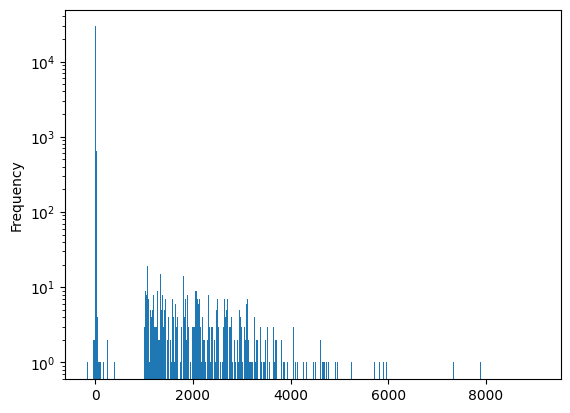

In [20]:
profit.difference.plot(kind='hist', bins=1000)
import matplotlib.pyplot as plt

plt.yscale('log')

# You can play with the plot, but results look really strange

#plt.xlim(-50, 50)
#.hist(bins= 50, figsize=(8,6));


### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

No plausible explanation for those values. Probably someone did somethin wrong. 
Anyway let's pretend everthing is fine and we go further...

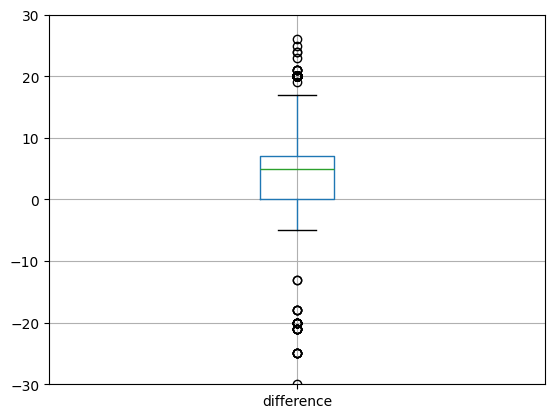

In [21]:
# We know this rule from the boxplot
import matplotlib.pyplot as plt

ax = profit.boxplot("difference");
ax.set_ylim(-30, +30)

# if you are brave enough you can try with different settings...
#ax.set_ylim(-300, +3000)

plt.show()

In [22]:
# we believe it's all about perspective
# smile and wave and calculate the quartiles
Q1 = profit["difference"].quantile(0.25)
Q3 = profit["difference"].quantile(0.75)
# now calculate IQR
IQR = Q3-Q1
# and finally the whiskers 
low = Q1 - 1.5*IQR
high = Q3 + 1.5*IQR
# and now filter the DataFrame to include only "non-outliers"
profit_f = profit.loc[
    (profit["difference"] >= (Q1 - 1.5*IQR))
    &
    (profit["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]
profit_f.shape

(41470, 7)

It seems as we had about 2000 outliers (43147 to 41470). Well done, lets check the results again...

### If there are differences that you can’t explain: what should you do with these orders?

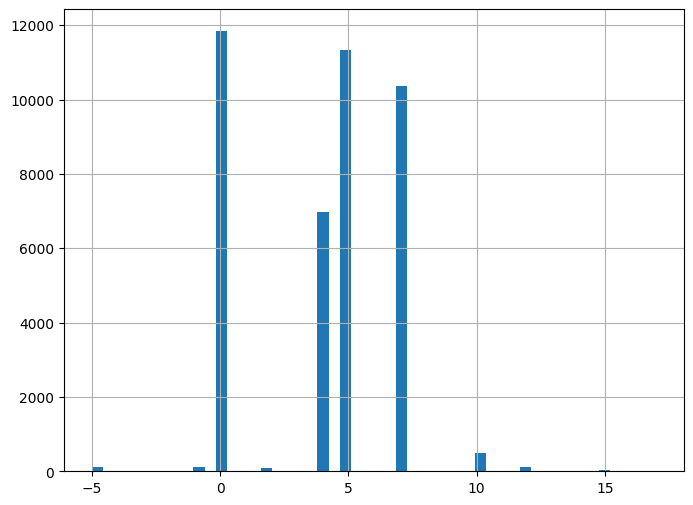

In [23]:
# clear stuff, we delete them, now our histogram looks amaizing!
profit_f.difference.hist(bins= 50, figsize=(8,6));

<Axes: >

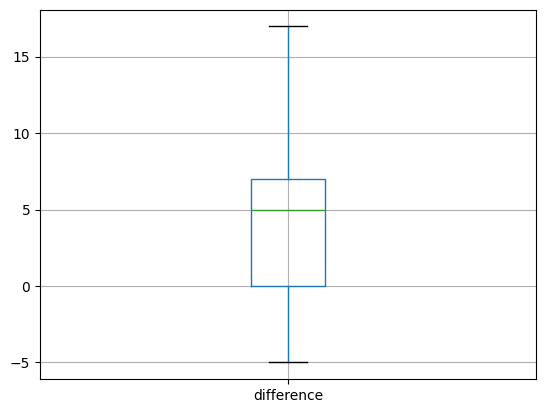

In [24]:
# and our boxplot as well!
profit_f.boxplot("difference")

In [25]:
# lets check again and make sure we have the data saved
# set up the mask
normal_profit_list = profit_f["order_id"]
# rewrite the orders_df without the outliers
orders_q = orders_q.loc[orders_q["order_id"].isin(normal_profit_list), :]
# rewrite the orderlines_df without the outliers
orderlines_q = orderlines_q.loc[orderlines_q["id_order"].isin(normal_profit_list), :]
# doublecheck they still match
orders_q["order_id"].nunique(), orderlines_q["id_order"].nunique()

(41470, 41470)

In [26]:
# one more time, we can save the df to csv
# orders_q.to_csv('../data/o_rev2.csv')
# orderlines_q.to_csv('../data/ol_rev2.csv')

Congratulations! We have amaizing data, we can try to plot something now...

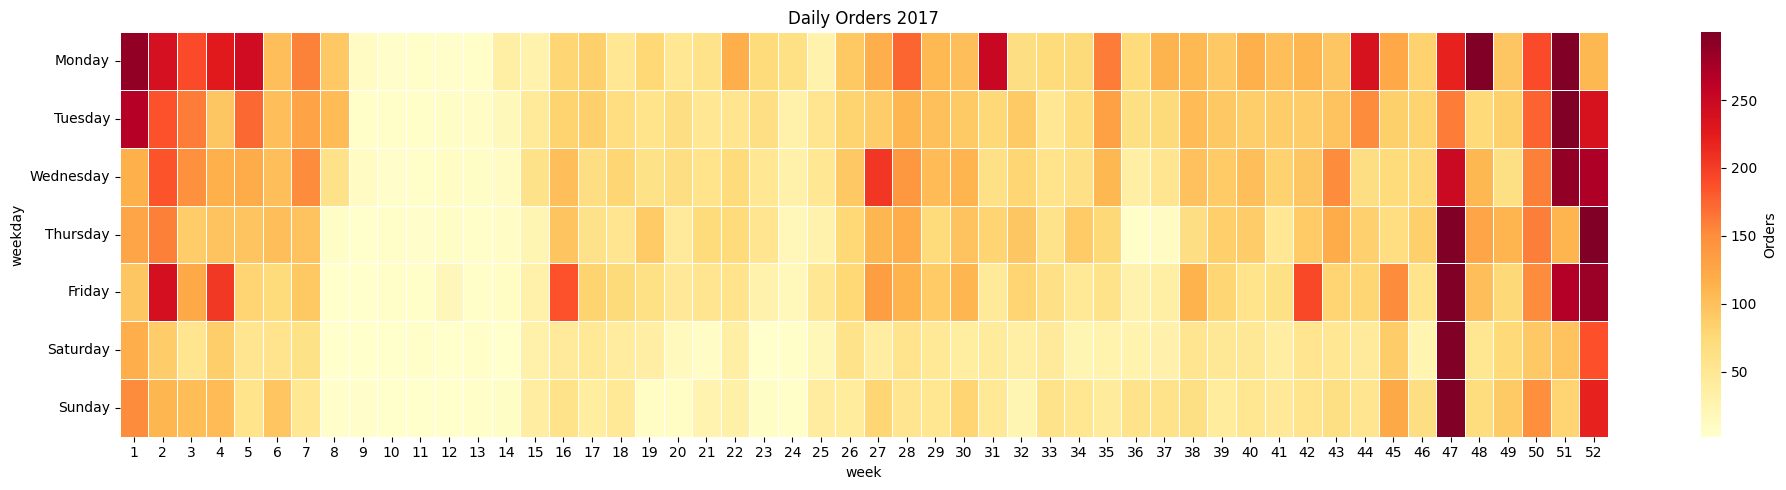

In [27]:
daily = orders_q.resample('D', on='created_date').count()['order_id']

df_heat = pd.DataFrame({'count': daily})
df_heat['weekday'] = daily.index.day_name()
df_heat['week'] = daily.index.isocalendar().week.astype(int)
df_heat['year'] = daily.index.year

df_heat = df_heat[df_heat['year'] == 2017]  # ← filter here

pivot = df_heat.pivot_table(index='weekday', columns='week', values='count', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Orders 2017')
plt.tight_layout()
# once you are ready with the figure, you can seve it in the proper folder
plt.savefig('../MyEniacProject/Presentation/figs/HM_avg_orders_2017.svg')
plt.show()

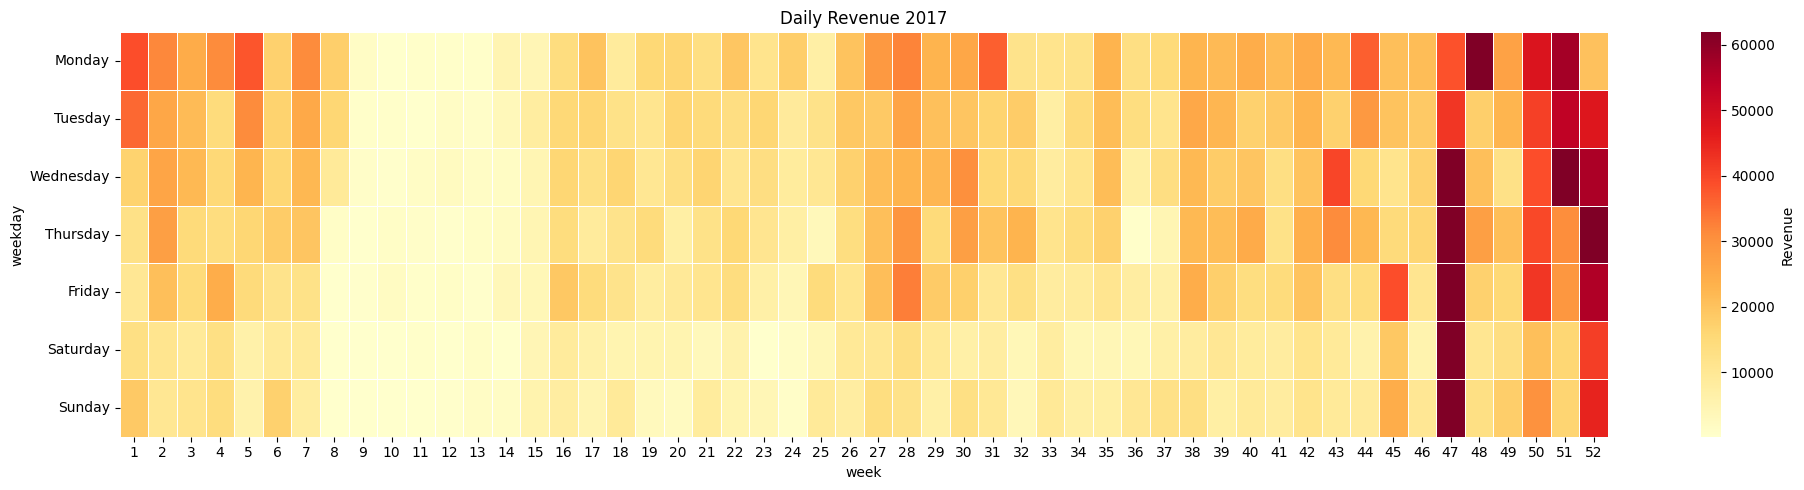

In [28]:
daily = orders_q.resample('D', on='created_date').sum()['total_paid']

df_heat2 = pd.DataFrame({'sum': daily})
df_heat2['weekday'] = daily.index.day_name()
df_heat2['week'] = daily.index.isocalendar().week.astype(int)
df_heat2['year'] = daily.index.year

df_heat2 = df_heat2[df_heat2['year'] == 2017]  # ← filter here

pivot = df_heat2.pivot_table(index='weekday', columns='week', values='sum', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Revenue'})
plt.title('Daily Revenue 2017')
plt.tight_layout()
# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/HM_avg_rev_2017.svg')
plt.show()

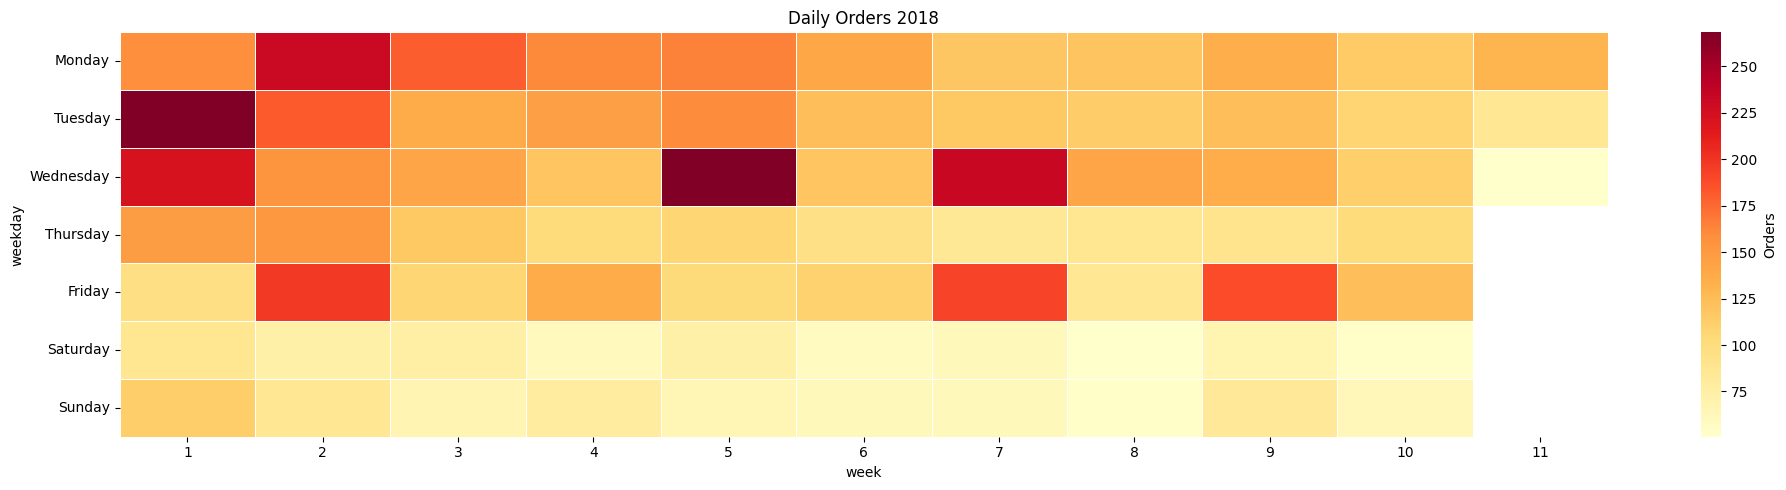

In [ ]:
daily = orders_q.resample('D', on='created_date').count()['order_id']

df_heat = pd.DataFrame({'count': daily})
df_heat['weekday'] = daily.index.day_name()
df_heat['week'] = daily.index.isocalendar().week.astype(int)
df_heat['year'] = daily.index.year

df_heat = df_heat[df_heat['year'] == 2018]  # ← filter here

pivot = df_heat.pivot_table(index='weekday', columns='week', values='count', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Orders 2018')
plt.tight_layout()
# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/HM_avg_orders_2018.svg')
plt.show()

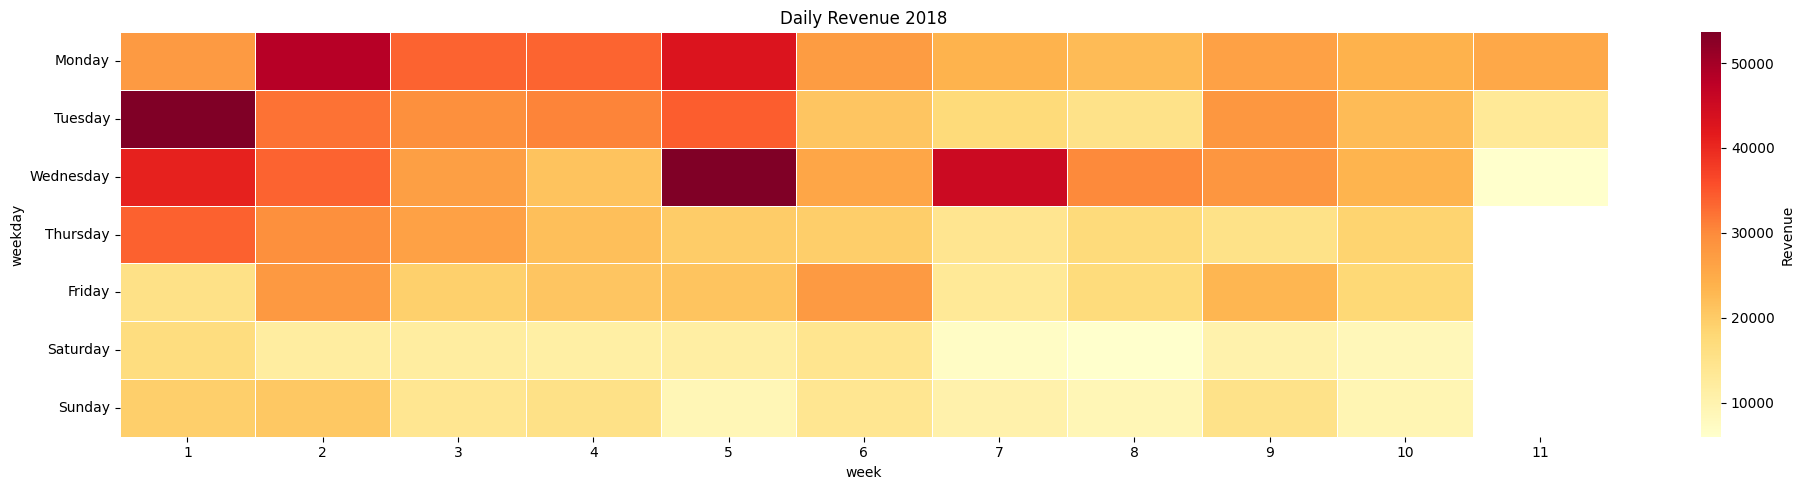

In [30]:
daily = orders_q.resample('D', on='created_date').sum()['total_paid']

df_heat2 = pd.DataFrame({'sum': daily})
df_heat2['weekday'] = daily.index.day_name()
df_heat2['week'] = daily.index.isocalendar().week.astype(int)
df_heat2['year'] = daily.index.year

df_heat2 = df_heat2[df_heat2['year'] == 2018]  # ← filter here

pivot = df_heat2.pivot_table(index='weekday', columns='week', values='sum', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot,  cmap='YlOrRd', linewidths=0.5, # annot=True,
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Revenue'})
plt.title('Daily Revenue 2018')
plt.tight_layout()
# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/HM_avg_rev_2018.svg')
plt.show()

In [31]:
df_data = df_heat.merge(df_heat2)
df_data

,count,weekday,week,year,sum
0,158,Monday,1,2018,27625.53
1,409,Tuesday,1,2018,76362.99
2,222,Wednesday,1,2018,40937.85
3,148,Thursday,1,2018,34009.55
4,97,Friday,1,2018,15541.39
...,...,...,...,...,...
68,54,Saturday,10,2018,8696.05
69,63,Sunday,10,2018,9482.44
70,130,Monday,11,2018,25381.93
71,86,Tuesday,11,2018,13381.64


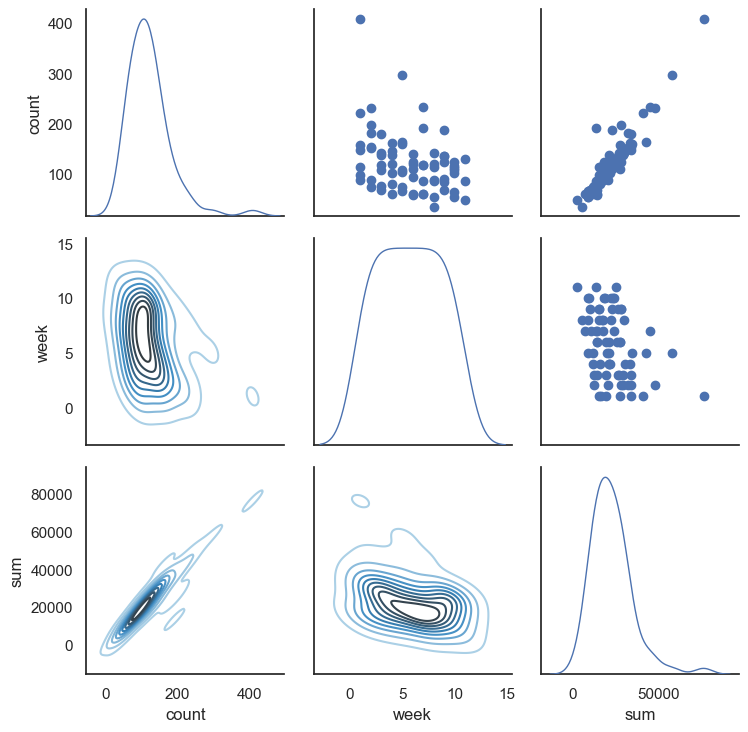

In [32]:
sns.set_theme(style = "white")
df = df_data.loc[:,["count","week","sum"]]
g = sns.PairGrid(df,diag_sharey = False,)
g.map_lower(sns.kdeplot,cmap="Blues_d")
g.map_upper(plt.scatter)
g.map_diag(sns.kdeplot,lw =1)
plt.show()

## 5.&nbsp; Become confident about your dataset

Let's hear your thoughts about what you discovered.

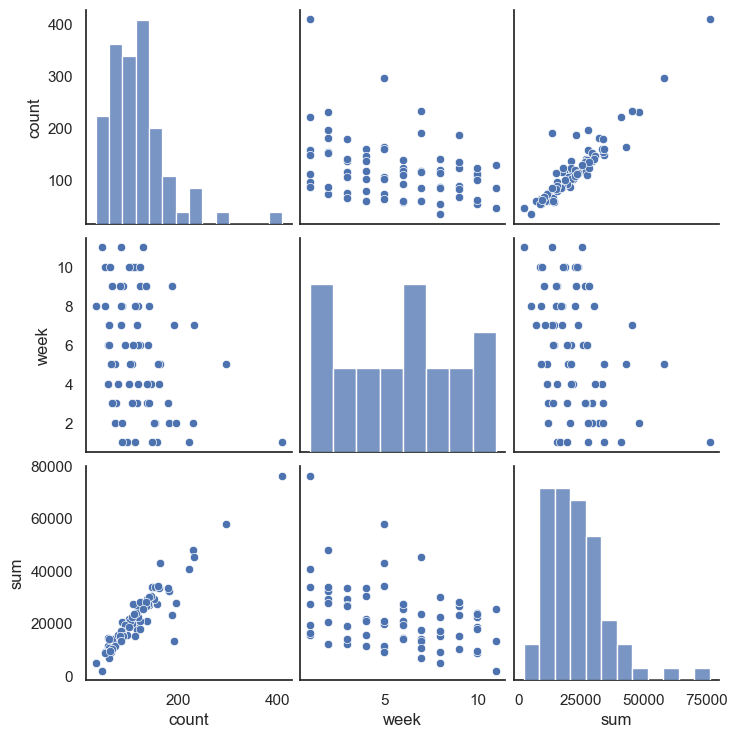

In [33]:
sns.set_theme(style = "white")
df = df_data.loc[:,["count","week","sum"]]
g = sns.pairplot(df,)

Do not forget to download your quality controlled DataFrames

In [34]:
#from google.colab import files

#orders_quality_controlled.to_csv("orders_qu.csv", index=False)
#files.download("orders_qu.csv")

#orderlines_quality_controlled.to_csv("orderlines_qu.csv", index=False)
#files.download("orderlines_qu.csv")